# Toponym Relation Error Analysis

Analyze misclassifications in the Relation Extraction pipeline's spatial category predictions (IN/NEAR/THRU/TO/FROM/NO_REL) against the gold standard.

This notebook reuses evaluation functions from `re_evaluate.py`.

In [33]:
import sys
import os
import json
import csv
import glob
import importlib.util
from pathlib import Path
from collections import Counter
from IPython.display import display, HTML

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Determine project root: the notebook lives in relation_extraction/, so parent is project root
# Fall back to cwd if that doesn't exist (e.g. running from project root)
notebook_dir = Path(os.path.abspath("")).resolve()
if notebook_dir.name == "relation_extraction":
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

# Load re_evaluate module from its file path (no __init__.py needed)
_re_eval_path = project_root / "relation_extraction" / "re_evaluate.py"
print(f"Loading re_evaluate from: {_re_eval_path}")
_spec = importlib.util.spec_from_file_location("re_evaluate", _re_eval_path)
_re_eval = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_re_eval)

# Reuse evaluation functions
load_gold_standard = _re_eval.load_gold_standard
load_mention_map = _re_eval.load_mention_map
load_events = _re_eval.load_events
derive_predictions = _re_eval.derive_predictions
match_gold_to_mention = _re_eval.match_gold_to_mention
evaluate_fine_grained = _re_eval.evaluate_fine_grained
evaluate_binary = _re_eval.evaluate_binary

# Figures dir + saver (mirrors re_run_comparison.ipynb).
FIG_DIR = project_root / "relation_extraction" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"saved {path}")

print("Imports OK")

Project root: /home/tijn-do/github/hist-dutch-travelogues-nlp
Loading re_evaluate from: /home/tijn-do/github/hist-dutch-travelogues-nlp/relation_extraction/re_evaluate.py
Imports OK


## 1. File Selection

Select an RE events JSON file from `output/re/`. The corresponding mention map is loaded automatically.

In [34]:
RE_DIR = project_root / "output" / "re"
GS_PATH = project_root / "relation_extraction" / "1816_re_gs.csv"
SOURCE_TEXT_PATH = project_root / "data" / "1816_third_letter.txt"

# Find available events JSON files
events_files = sorted(RE_DIR.glob("*_events.json"))
print(f"Found {len(events_files)} RE output file(s):\n")
for i, f in enumerate(events_files, 1):
    print(f"  [{i}] {f.name}")

if len(events_files) == 0:
    raise FileNotFoundError("No *_events.json files found in output/re/. Run rel_extraction.py first.")

# Interactive selection when multiple files exist
if len(events_files) == 1:
    selected = events_files[0]
    print(f"\nAuto-selected: {selected.name}")
else:
    print(f"\nSelect file number [1-{len(events_files)}]:")
    choice = input().strip()
    try:
        idx = int(choice) - 1
        if 0 <= idx < len(events_files):
            selected = events_files[idx]
        else:
            print(f"Invalid selection: {choice}, defaulting to first file.")
            selected = events_files[0]
    except ValueError:
        print(f"Invalid input: {choice}, defaulting to first file.")
        selected = events_files[0]
    print(f"\nSelected: {selected.name}")

# Derive mention map path
stem = selected.stem  # e.g. "1816_el_gs__gemma4_31b_t0.7_events"
if stem.endswith("_events"):
    base = stem[:-7]
else:
    base = stem
mention_map_path = RE_DIR / f"{base}_mention_map.json"

# Tag for saved figure filenames so re-running on a different model doesn't
# silently overwrite the previous run's figures.
RUN_TAG = base

# Clean model name for figure titles (parsed with re_evaluate's own slug
# rules, the single source of truth).
_sel_model, _sel_temp, _sel_think = _re_eval.extract_model_from_filename(str(selected))
MODEL_NAME = _sel_model or base

print(f"Events JSON:    {selected.name}")
print(f"Mention map:    {mention_map_path.name if mention_map_path.exists() else 'NOT FOUND'}")
print(f"Gold standard:  {GS_PATH.name}")
print(f"Source text:    {SOURCE_TEXT_PATH.name}")
print(f"Run tag:        {RUN_TAG}")
print(f"Model:          {MODEL_NAME}")

Found 8 RE output file(s):

  [1] 1816_el_gs__deepseek-v4-flash_t0.0_thinkDefault_events.json
  [2] 1816_el_gs__deepseek-v4-pro_t0.0_thinkDefault_events.json
  [3] 1816_el_gs__gemma4_31b_t0.0_thinkDefault_events.json
  [4] 1816_el_gs__glm-5.1_t0.0_thinkDefault_events.json
  [5] 1816_el_gs__glm-5.2_t0.0_thinkDefault_events.json
  [6] 1816_el_gs__kimi-k2.7-code_t0.0_thinkDefault_events.json
  [7] 1816_el_gs__mistral-large-3_675b_t0.0_thinkDefault_events.json
  [8] 1816_el_gs__qwen3.5_397b_t0.0_thinkDefault_events.json

Select file number [1-8]:

Selected: 1816_el_gs__glm-5.1_t0.0_thinkDefault_events.json
Events JSON:    1816_el_gs__glm-5.1_t0.0_thinkDefault_events.json
Mention map:    1816_el_gs__glm-5.1_t0.0_thinkDefault_mention_map.json
Gold standard:  1816_re_gs.csv
Source text:    1816_third_letter.txt
Run tag:        1816_el_gs__glm-5.1_t0.0_thinkDefault
Model:          glm-5.1


In [35]:
# Load all data
gold_entities = load_gold_standard(str(GS_PATH))
mention_map = load_mention_map(str(mention_map_path))
events_data = load_events(str(selected))

# Load source text for context display
with open(SOURCE_TEXT_PATH, encoding="utf-8") as f:
    source_text = f.read()

# Derive predictions
predictions = derive_predictions(events_data, mention_map)

# Match gold to mention_map
matches = match_gold_to_mention(gold_entities, mention_map)

print(f"Gold standard E53/E18 with visited_type: {len(gold_entities)}")
print(f"Mention map entries:                    {len(mention_map)}")
print(f"Gold–mention matches:                   {len(matches)}")
print(f"Source text length:                     {len(source_text)} chars")

Gold standard E53/E18 with visited_type: 170
Mention map entries:                    313
Gold–mention matches:                   169
Source text length:                     21447 chars


## 2. Aggregate Overview

Distribution comparison, per-category metrics, and confusion matrix.

saved /home/tijn-do/github/hist-dutch-travelogues-nlp/relation_extraction/figures/1816_el_gs__glm-5.1_t0.0_thinkDefault_category_distribution.png


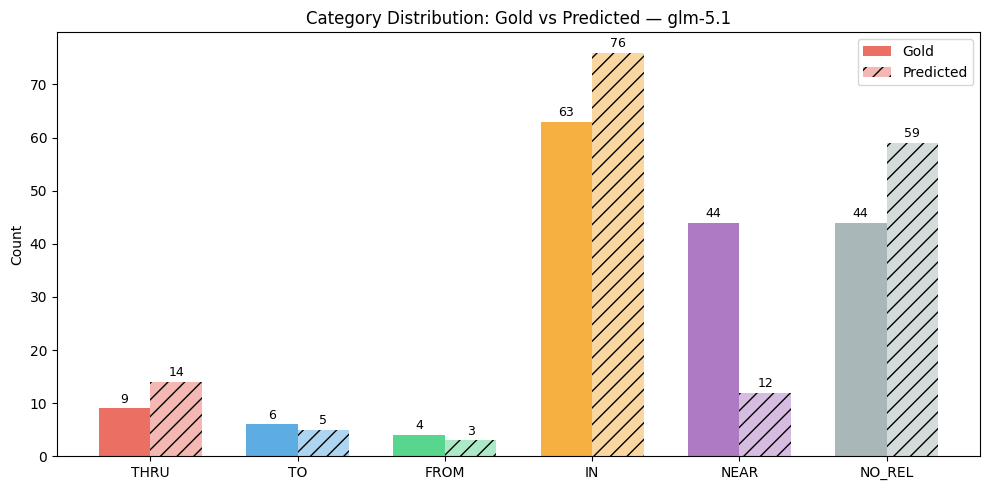

,Gold,Predicted
THRU,9,14
TO,6,5
FROM,4,3
IN,63,76
NEAR,44,12
NO_REL,44,59


In [36]:
# Count gold and predicted categories
CATEGORIES = ["THRU", "TO", "FROM", "IN", "NEAR", "NO_REL"]
CAT_COLORS = {"THRU": "#e74c3c", "TO": "#3498db", "FROM": "#2ecc71",
              "IN": "#f39c12", "NEAR": "#9b59b6", "NO_REL": "#95a5a6"}

gold_counts = Counter(g["visited_type"] for g in gold_entities)

pred_counts = Counter()
for mid, cat in predictions.items():
    info = mention_map.get(mid, {})
    if info.get("label") in ("E53_Place", "E18_Physical_Thing"):
        pred_counts[cat] += 1

# Build DataFrame for plotting
dist_df = pd.DataFrame({
    "Gold": [gold_counts.get(c, 0) for c in CATEGORIES],
    "Predicted": [pred_counts.get(c, 0) for c in CATEGORIES],
}, index=CATEGORIES)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CATEGORIES))
width = 0.35

bars1 = ax.bar(x - width/2, dist_df["Gold"], width, label="Gold", color=[CAT_COLORS[c] for c in CATEGORIES], alpha=0.8)
bars2 = ax.bar(x + width/2, dist_df["Predicted"], width, label="Predicted", color=[CAT_COLORS[c] for c in CATEGORIES], alpha=0.4, hatch="//")

ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES)
ax.set_ylabel("Count")
ax.set_title(f"Category Distribution: Gold vs Predicted — {MODEL_NAME}")
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
save_fig(fig, f"{RUN_TAG}_category_distribution")
plt.show()

display(dist_df)

In [37]:
# Per-category precision/recall/F1
fine_results, fine_summary = evaluate_fine_grained(gold_entities, predictions, mention_map)

metrics_rows = []
for cat in CATEGORIES:
    r = fine_results[cat]
    metrics_rows.append({
        "Category": cat,
        "TP": r["tp"],
        "FP": r["fp"],
        "FN": r["fn"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
    })

metrics_df = pd.DataFrame(metrics_rows)

# Add macro/micro summary row
summary_row = pd.DataFrame([{
    "Category": "MACRO AVG",
    "TP": "", "FP": "", "FN": "",
    "Precision": fine_summary["macro_precision"],
    "Recall": fine_summary["macro_recall"],
    "F1": fine_summary["macro_f1"],
}])
summary_row2 = pd.DataFrame([{
    "Category": "MICRO AVG",
    "TP": "", "FP": "", "FN": "",
    "Precision": "", "Recall": "",
    "F1": fine_summary["micro_f1"],
}])

display(metrics_df)
display(summary_row)
display(summary_row2)

print(f"Total matched entities: {fine_summary['matched']} / {fine_summary['total']}")

,Category,TP,FP,FN,Precision,Recall,F1
0,THRU,5,9,4,0.357,0.556,0.435
1,TO,5,0,1,1.000,0.833,0.909
2,FROM,2,1,2,0.667,0.500,0.571
3,IN,52,24,11,0.684,0.825,0.748
4,NEAR,10,2,34,0.833,0.227,0.357
5,NO_REL,42,17,1,0.712,0.977,0.824


,Category,TP,FP,FN,Precision,Recall,F1
0,MACRO AVG,,,,0.709,0.653,0.68


,Category,TP,FP,FN,Precision,Recall,F1
0,MICRO AVG,,,,,,0.686


Total matched entities: 169 / 169


saved /home/tijn-do/github/hist-dutch-travelogues-nlp/relation_extraction/figures/1816_el_gs__glm-5.1_t0.0_thinkDefault_confusion_matrix.png


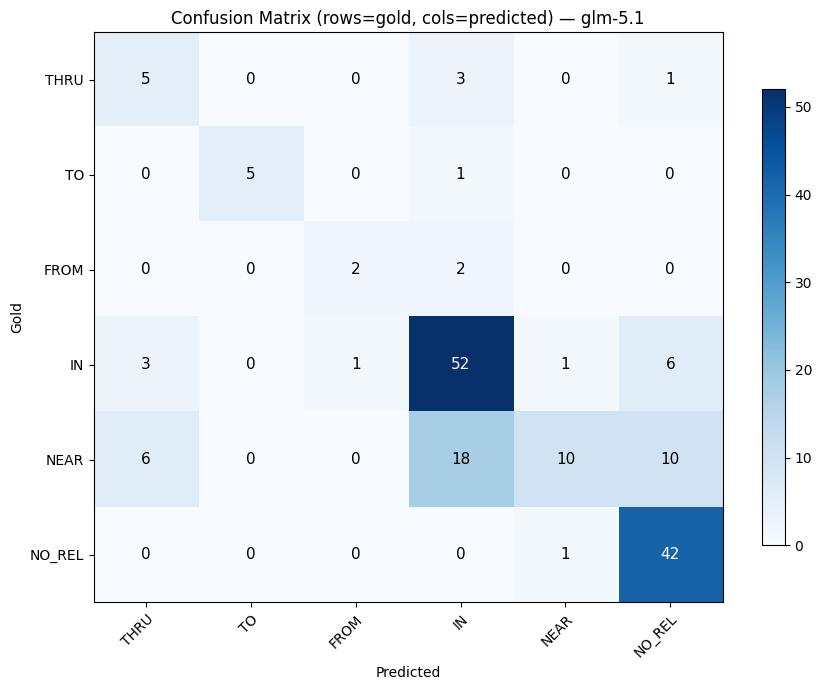

In [38]:
# Build confusion matrix
cm = {g: {p: 0 for p in CATEGORIES} for g in CATEGORIES}
for g, mid in matches:
    gold = g["visited_type"]
    pred = predictions.get(mid, "NEAR")
    if gold in cm and pred in cm[gold]:
        cm[gold][pred] += 1

cm_array = np.array([[cm[g][p] for p in CATEGORIES] for g in CATEGORIES])

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm_array, cmap="Blues", aspect="auto")

# Show all ticks and label them
ax.set_xticks(np.arange(len(CATEGORIES)))
ax.set_yticks(np.arange(len(CATEGORIES)))
ax.set_xticklabels(CATEGORIES)
ax.set_yticklabels(CATEGORIES)

# Rotate the tick labels and set alignment
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Loop over data dimensions and create text annotations
for i in range(len(CATEGORIES)):
    for j in range(len(CATEGORIES)):
        color = "white" if cm_array[i, j] > cm_array.max() * 0.6 else "black"
        ax.text(j, i, str(cm_array[i, j]), ha="center", va="center", color=color, fontsize=11)

ax.set_xlabel("Predicted")
ax.set_ylabel("Gold")
ax.set_title(f"Confusion Matrix (rows=gold, cols=predicted) — {MODEL_NAME}")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
save_fig(fig, f"{RUN_TAG}_confusion_matrix")
plt.show()

In [39]:
# Binary visited vs non-visited
bin_results = evaluate_binary(gold_entities, predictions, mention_map)

bin_df = pd.DataFrame([{
    "Metric": k,
    "Value": v
} for k, v in bin_results.items()])
display(bin_df)

print(f"\nVisited (THRU/TO/FROM/IN/NEAR) vs Non-visited (NO_REL)")
print(f"Precision: {bin_results['precision']:.3f}  Recall: {bin_results['recall']:.3f}  F1: {bin_results['f1']:.3f}  Accuracy: {bin_results['accuracy']:.3f}")

,Metric,Value
0,tp,109.000
1,fp,1.000
2,fn,17.000
3,tn,42.000
4,precision,0.991
5,recall,0.865
6,f1,0.924
7,accuracy,0.893
8,total,169.000



Visited (THRU/TO/FROM/IN/NEAR) vs Non-visited (NO_REL)
Precision: 0.991  Recall: 0.865  F1: 0.924  Accuracy: 0.893


## 3. Error Detail Table

Every matched entity with its gold vs predicted category, sortable and filterable.

In [40]:
rows = []
for g, mid in matches:
    gold_cat = g["visited_type"]
    pred_cat = predictions.get(mid, "NEAR")
    info = mention_map.get(mid, {})
    rows.append({
        "mention_id": mid,
        "text": g["text"],
        "label": g["label"],
        "gold": gold_cat,
        "pred": pred_cat,
        "correct": gold_cat == pred_cat,
        "error_type": f"{gold_cat}→{pred_cat}" if gold_cat != pred_cat else "✓",
        "note": g.get("note", ""),
        "gold_start": g["start"],
        "gold_end": g["end"],
    })

detail_df = pd.DataFrame(rows)

print(f"Total matched: {len(detail_df)}")
print(f"Correct:       {detail_df['correct'].sum()}")
print(f"Incorrect:     {(~detail_df['correct']).sum()}")
print(f"Accuracy:      {detail_df['correct'].mean():.3f}")

# Show all rows (no truncation)
display(detail_df)

Total matched: 169
Correct:       116
Incorrect:     53
Accuracy:      0.686


,mention_id,text,label,gold,pred,correct,error_type,note,gold_start,gold_end
0,e2,Cassel,E53_Place,IN,IN,True,✓,,21,27
1,e5,Paderborn,E53_Place,IN,FROM,False,IN→FROM,,119,128
2,e8,Warburg,E53_Place,IN,IN,True,✓,,210,217
3,e11,Paderborn,E53_Place,IN,NO_REL,False,IN→NO_REL,,314,323
4,e12,Cassel,E53_Place,NO_REL,NO_REL,True,✓,,404,410
...,...,...,...,...,...,...,...,...,...,...
164,e309,Konings,E53_Place,IN,IN,True,✓,,21169,21176
165,e310,Bellevue straat,E53_Place,IN,IN,True,✓,,21183,21198
166,e311,boven nieuwstad,E53_Place,IN,IN,True,✓,,21211,21226
167,e312,Wilhelmshöhe,E18_Physical_Thing,NO_REL,NO_REL,True,✓,,21360,21372


In [41]:
# Filter to only errors
errors_df = detail_df[~detail_df["correct"]].copy()
print(f"Total errors: {len(errors_df)}")
display(errors_df)

Total errors: 53


,mention_id,text,label,gold,pred,correct,error_type,note,gold_start,gold_end
1,e5,Paderborn,E53_Place,IN,FROM,False,IN→FROM,,119,128
3,e11,Paderborn,E53_Place,IN,NO_REL,False,IN→NO_REL,,314,323
6,e18,Hoxenberg,E18_Physical_Thing,THRU,NO_REL,False,THRU→NO_REL,,622,631
16,e48,hooge bergen,E18_Physical_Thing,IN,NEAR,False,IN→NEAR,,3341,3353
17,e49,bergen,E18_Physical_Thing,NEAR,THRU,False,NEAR→THRU,,3448,3454
19,e53,uitgestrekt bosch,E53_Place,IN,THRU,False,IN→THRU,,3859,3876
20,e54,Hardehauserwoud,E53_Place,IN,THRU,False,IN→THRU,,3900,3915
21,e55,klooster,E18_Physical_Thing,NO_REL,NEAR,False,NO_REL→NEAR,,3933,3941
23,e58,Warburg,E53_Place,NEAR,NO_REL,False,NEAR→NO_REL,,4071,4078
25,e61,posthuis,E18_Physical_Thing,NEAR,NO_REL,False,NEAR→NO_REL,,4202,4210


## 4. Error Pattern Analysis

Break down what the model struggles with.

Most common confusion pairs (gold→pred):


,Count
error_type,
NEAR→IN,18
NEAR→NO_REL,10
IN→NO_REL,6
NEAR→THRU,6
THRU→IN,3
IN→THRU,3
FROM→IN,2
IN→FROM,1
IN→NEAR,1


saved /home/tijn-do/github/hist-dutch-travelogues-nlp/relation_extraction/figures/1816_el_gs__glm-5.1_t0.0_thinkDefault_confusion_pairs.png


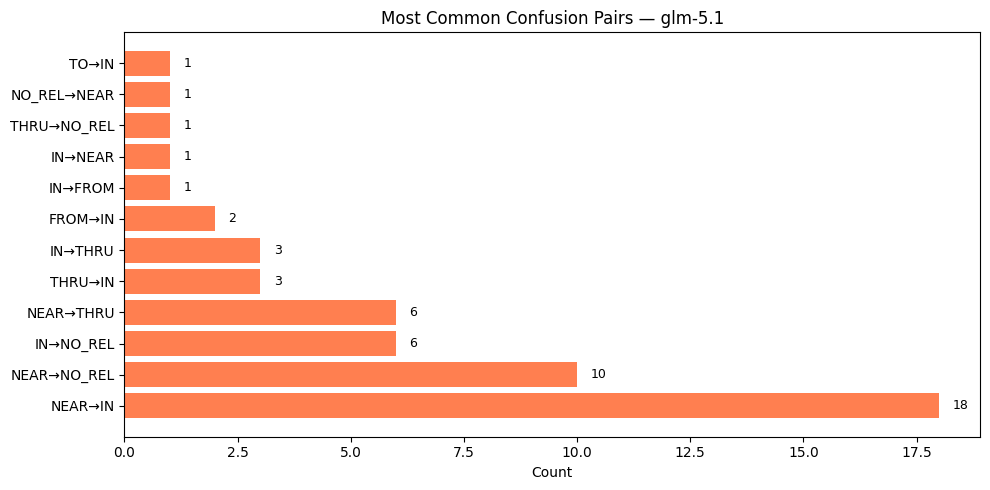

In [42]:
# Most common confusion pairs
error_types = errors_df["error_type"].value_counts()
print("Most common confusion pairs (gold→pred):")
display(error_types.to_frame("Count"))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(error_types)), error_types.values, color="coral")
ax.set_yticks(range(len(error_types)))
ax.set_yticklabels(error_types.index)
ax.set_xlabel("Count")
ax.set_title(f"Most Common Confusion Pairs — {MODEL_NAME}")
for bar, v in zip(bars, error_types.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(v), ha="left", va="center", fontsize=9)
plt.tight_layout()
save_fig(fig, f"{RUN_TAG}_confusion_pairs")
plt.show()


E53_Place (107 entities, 81/107 correct = 75.7%)
saved /home/tijn-do/github/hist-dutch-travelogues-nlp/relation_extraction/figures/1816_el_gs__glm-5.1_t0.0_thinkDefault_confusion_matrix_E53_Place.png


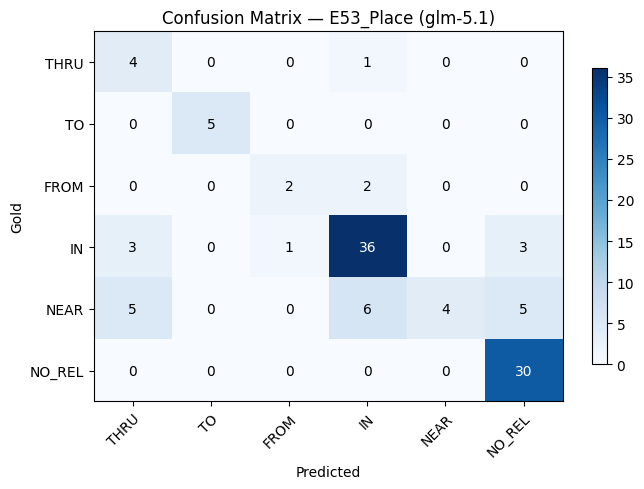


E18_Physical_Thing (62 entities, 35/62 correct = 56.5%)
saved /home/tijn-do/github/hist-dutch-travelogues-nlp/relation_extraction/figures/1816_el_gs__glm-5.1_t0.0_thinkDefault_confusion_matrix_E18_Physical_Thing.png


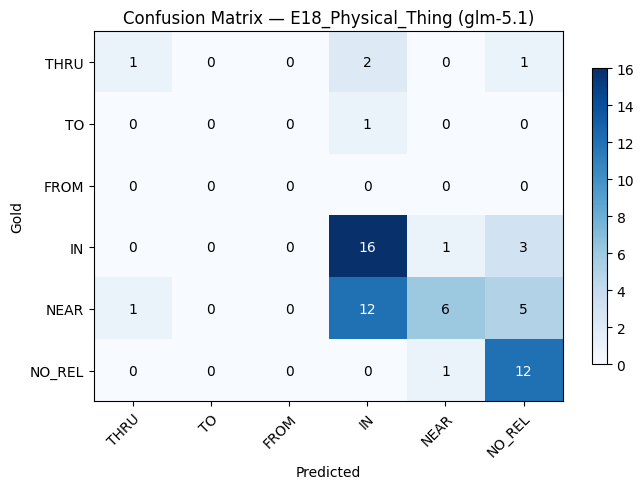

In [43]:
# Per-label confusion
for label in ["E53_Place", "E18_Physical_Thing"]:
    subset = detail_df[detail_df["label"] == label]
    correct = subset["correct"].sum()
    total = len(subset)
    print(f"\n{'='*50}")
    print(f"{label} ({total} entities, {correct}/{total} correct = {correct/total*100:.1f}%)")
    print('='*50)
    
    # Confusion matrix for this label
    cm_label = {g: {p: 0 for p in CATEGORIES} for g in CATEGORIES}
    for _, row in subset.iterrows():
        cm_label[row["gold"]][row["pred"]] += 1
    
    cm_lbl_array = np.array([[cm_label[g][p] for p in CATEGORIES] for g in CATEGORIES])
    
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(cm_lbl_array, cmap="Blues", aspect="auto")
    ax.set_xticks(np.arange(len(CATEGORIES)))
    ax.set_yticks(np.arange(len(CATEGORIES)))
    ax.set_xticklabels(CATEGORIES)
    ax.set_yticklabels(CATEGORIES)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    for i in range(len(CATEGORIES)):
        for j in range(len(CATEGORIES)):
            color = "white" if cm_lbl_array[i, j] > cm_lbl_array.max() * 0.6 else "black"
            ax.text(j, i, str(cm_lbl_array[i, j]), ha="center", va="center", color=color, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Gold")
    ax.set_title(f"Confusion Matrix — {label} ({MODEL_NAME})")
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    save_fig(fig, f"{RUN_TAG}_confusion_matrix_{label}")
    plt.show()

Entity texts most frequently misclassified:


,Error Count
text,
Paderborn,2
Warburg,2
galery,2
Hoxenberg,1
uitgestrekt bosch,1
hooge bergen,1
Hardehauserwoud,1
klooster,1
posthuis,1


saved /home/tijn-do/github/hist-dutch-travelogues-nlp/relation_extraction/figures/1816_el_gs__glm-5.1_t0.0_thinkDefault_misclassified_texts.png


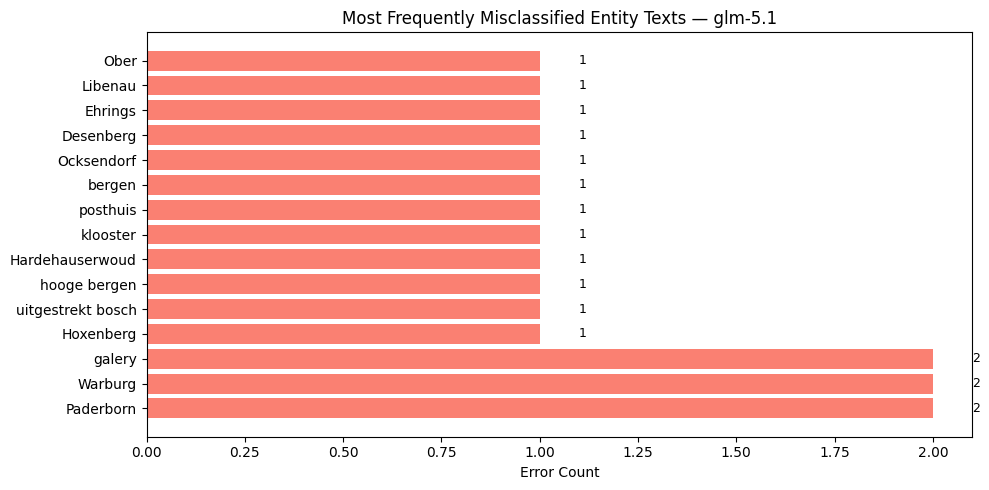


--- Detail for top misclassified entities ---

  'Paderborn' — 2 errors:
    IN → FROM  (mention_id=e5, note: -)
    IN → NO_REL  (mention_id=e11, note: -)

  'Warburg' — 2 errors:
    NEAR → NO_REL  (mention_id=e58, note: -)
    NEAR → IN  (mention_id=e77, note: -)

  'galery' — 2 errors:
    NEAR → IN  (mention_id=e255, note: -)
    NEAR → IN  (mention_id=e257, note: -)


In [44]:
# Which entity texts are most often misclassified?
text_error_counts = errors_df["text"].value_counts().head(15)

print("Entity texts most frequently misclassified:")
display(text_error_counts.to_frame("Error Count"))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(text_error_counts)), text_error_counts.values, color="salmon")
ax.set_yticks(range(len(text_error_counts)))
ax.set_yticklabels(text_error_counts.index)
ax.set_xlabel("Error Count")
ax.set_title(f"Most Frequently Misclassified Entity Texts — {MODEL_NAME}")
for bar, v in zip(bars, text_error_counts.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(v), ha="left", va="center", fontsize=9)
plt.tight_layout()
save_fig(fig, f"{RUN_TAG}_misclassified_texts")
plt.show()

# Show detail for top-3 most misclassified texts
print("\n--- Detail for top misclassified entities ---")
for text in text_error_counts.index[:3]:
    subset = errors_df[errors_df["text"] == text]
    print(f"\n  '{text}' — {len(subset)} errors:")
    for _, row in subset.iterrows():
        print(f"    {row['gold']} → {row['pred']}  (mention_id={row['mention_id']}, note: {row['note'][:60] if row['note'] else '-'})")

In [45]:
# Do entities that appear many times get classified inconsistently?
text_freq = detail_df["text"].value_counts()
multi_occurrence = text_freq[text_freq > 1].index

print(f"Entities appearing multiple times: {len(multi_occurrence)}")

inconsistent = []
for text in multi_occurrence:
    subset = detail_df[detail_df["text"] == text]
    unique_gold = subset["gold"].unique()
    unique_pred = subset["pred"].unique()
    n_correct = subset["correct"].sum()
    n_total = len(subset)
    inconsistent.append({
        "text": text,
        "occurrences": n_total,
        "correct": n_correct,
        "accuracy": n_correct / n_total,
        "gold_categories": ", ".join(sorted(unique_gold)),
        "pred_categories": ", ".join(sorted(unique_pred)),
        "all_correct": n_correct == n_total,
    })

freq_df = pd.DataFrame(inconsistent).sort_values("occurrences", ascending=False)
display(freq_df)

# Show entities where the model disagrees with itself (same text, different predictions)
print("\n--- Entities where model predicts DIFFERENT categories for same text ---")
self_inconsistent = freq_df[freq_df["pred_categories"].str.contains(",")]
if len(self_inconsistent) > 0:
    display(self_inconsistent)
else:
    print("(none — model is consistent in its predictions per text)")

Entities appearing multiple times: 14


,text,occurrences,correct,accuracy,gold_categories,pred_categories,all_correct
0,Cassel,17,16,0.941176,"IN, NO_REL, TO","IN, NO_REL, TO",False
1,Paderborn,6,4,0.666667,"FROM, IN, NEAR, NO_REL","FROM, NEAR, NO_REL",False
2,Warburg,6,4,0.666667,"FROM, IN, NEAR, TO","FROM, IN, NEAR, NO_REL, TO",False
3,Parys,4,4,1.000000,NO_REL,NO_REL,True
4,Desenberg,3,2,0.666667,NEAR,"NEAR, NO_REL",False
5,kamer,3,3,1.000000,IN,IN,True
6,gebouw,3,2,0.666667,"IN, NEAR","IN, NEAR, NO_REL",False
7,museum,2,1,0.500000,"IN, TO",IN,False
8,Ossendorf,2,2,1.000000,"NO_REL, TO","NO_REL, TO",True
9,Ocksendorf,2,1,0.500000,"FROM, NO_REL","IN, NO_REL",False



--- Entities where model predicts DIFFERENT categories for same text ---


,text,occurrences,correct,accuracy,gold_categories,pred_categories,all_correct
0,Cassel,17,16,0.941176,"IN, NO_REL, TO","IN, NO_REL, TO",False
1,Paderborn,6,4,0.666667,"FROM, IN, NEAR, NO_REL","FROM, NEAR, NO_REL",False
2,Warburg,6,4,0.666667,"FROM, IN, NEAR, TO","FROM, IN, NEAR, NO_REL, TO",False
4,Desenberg,3,2,0.666667,NEAR,"NEAR, NO_REL",False
6,gebouw,3,2,0.666667,"IN, NEAR","IN, NEAR, NO_REL",False
8,Ossendorf,2,2,1.000000,"NO_REL, TO","NO_REL, TO",True
9,Ocksendorf,2,1,0.500000,"FROM, NO_REL","IN, NO_REL",False


## 5. Contextual Error Viewer

Pick an error type or entity text to see the surrounding context from the source text.

In [46]:
def show_context(error_type_filter=None, text_filter=None, context_chars=120):
    """Display errors with surrounding source text context."""
    subset = errors_df.copy()
    if error_type_filter:
        subset = subset[subset["error_type"] == error_type_filter]
    if text_filter:
        subset = subset[subset["text"].str.contains(text_filter, case=False, na=False)]
    
    if len(subset) == 0:
        print("No matching errors.")
        return
    
    print(f"Showing {len(subset)} error(s):\n")
    
    for idx, (_, row) in enumerate(subset.iterrows()):
        start = max(0, row["gold_start"] - context_chars)
        end = min(len(source_text), row["gold_end"] + context_chars)
        
        before = source_text[start:row["gold_start"]]
        entity_text = source_text[row["gold_start"]:row["gold_end"]]
        after = source_text[row["gold_end"]:end]
        
        print(f"{'='*70}")
        print(f"[{idx+1}] Entity: \"{row['text']}\"  ({row['label']})")
        print(f"    Gold: {row['gold']}  →  Pred: {row['pred']}  ({row['error_type']})")
        if row['note']:
            print(f"    Note: {row['note']}")
        print(f"    Mention ID: {row['mention_id']}")
        print(f"    Context: ...{before}|{entity_text}|{after}...")
        print()


# Show available error types
error_types_list = sorted(errors_df["error_type"].unique())
print("Available error types:")
for et in error_types_list:
    count = len(errors_df[errors_df["error_type"] == et])
    print(f"  {et} ({count})")
print()

# Show the most common error type by default
if len(error_types_list) > 0:
    most_common = errors_df["error_type"].value_counts().index[0]
    print(f"Showing context for most common error type: {most_common}")
    show_context(error_type_filter=most_common)
else:
    print("No errors to display.")

Available error types:
  FROM→IN (2)
  IN→FROM (1)
  IN→NEAR (1)
  IN→NO_REL (6)
  IN→THRU (3)
  NEAR→IN (18)
  NEAR→NO_REL (10)
  NEAR→THRU (6)
  NO_REL→NEAR (1)
  THRU→IN (3)
  THRU→NO_REL (1)
  TO→IN (1)

Showing context for most common error type: NEAR→IN
Showing 18 error(s):

[1] Entity: "Warburg"  (E53_Place)
    Gold: NEAR  →  Pred: IN  (NEAR→IN)
    Mention ID: e77
    Context: ... de andere Heeren hebben dien nagt weder doorgereden & des morgens hier te Cassel gekomen terwyl wy tot donkeren toe om |Warburg| allerliefste wandelingen gedaan, zeer goed gegeten, en schoon slegte bedden hebbende heerlyk geslapen hebben. –
Met een...

[2] Entity: "muren"  (E18_Physical_Thing)
    Gold: NEAR  →  Pred: IN  (NEAR→IN)
    Mention ID: e233
    Context: ...dens gekost heeft, is door de beroemden beeldhouwer P.S. Monnot gemaakt het is een vierkant vertrek waarvan de vloeren, |muren| en vercierselen uit verschillende soorten van zeldsaam marmer, uit jaspis agaat & andere steenen bestaan. He

In [47]:
# Search by entity text — show a few examples by default
# Show context for the most frequently misclassified entity text
if len(errors_df) > 0:
    top_text = errors_df["text"].value_counts().index[0]
    print(f"Showing context for most frequently misclassified entity: \"{top_text}\"")
    show_context(text_filter=f"^{top_text}$")
else:
    print("No errors to display.")

Showing context for most frequently misclassified entity: "Paderborn"
Showing 2 error(s):

[1] Entity: "Paderborn"  (E53_Place)
    Gold: IN  →  Pred: FROM  (IN→FROM)
    Mention ID: e5
    Context: ...﻿[16]
Derde Brief.


Cassel den 7 July 1816.


Amice!


Juist zoo als ik gedagt had, dat wy niet in eene halve dag van |Paderborn| herwaarts zouden ryden, is het ook uitgevallen; wy zyn dien nagt fraay en wel te Warburg gebleven en niet voor de volge...

[2] Entity: "Paderborn"  (E53_Place)
    Gold: IN  →  Pred: NO_REL  (IN→NO_REL)
    Mention ID: e11
    Context: ...fraay en wel te Warburg gebleven en niet voor de volgende avond 5 uuren alhier gearriveerd, doch verplaats u weder naar |Paderborn| en ik zal u zoo kort mogelyk onze verdere reis mededeelen om zoo veel te langer Cassel met u op het papier te kunnen ro...



## 6. Summary & Key Findings

In [48]:
total = len(detail_df)
correct = detail_df["correct"].sum()
incorrect = total - correct
accuracy = correct / total if total > 0 else 0

print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nTotal matched entities:  {total}")
print(f"Correct:                 {correct} ({accuracy*100:.1f}%)")
print(f"Incorrect:               {incorrect} ({(1-accuracy)*100:.1f}%)")
print()
print(f"Macro F1 (6 categories): {fine_summary['macro_f1']:.3f}")
print(f"Micro F1 (accuracy):     {fine_summary['micro_f1']:.3f}")
print(f"Binary visited F1:       {bin_results['f1']:.3f}")
print()
print("-" * 60)
print("Per-category F1:")
for cat in CATEGORIES:
    r = fine_results[cat]
    print(f"  {cat:>8}: {r['f1']:.3f}  (TP={r['tp']}, FP={r['fp']}, FN={r['fn']})")
print()
print("-" * 60)
print("Top-3 confusion pairs:")
top_confusions = error_types.head(3) if len(error_types) > 0 else []
for pair, count in top_confusions.items():
    print(f"  {pair}: {count}")
print()
print("-" * 60)
print("Key observations:")

# Generate observations
observations = []

# 1. Most confused pair
if len(error_types) > 0:
    worst_pair = error_types.index[0]
    worst_count = error_types.values[0]
    observations.append(f"The most common error is {worst_pair} ({worst_count} cases).")

# 2. Category with lowest F1
worst_cat = min(CATEGORIES, key=lambda c: fine_results[c]["f1"])
observations.append(f"The hardest category is {worst_cat} (F1={fine_results[worst_cat]['f1']:.3f}).")

# 3. Category with highest F1
best_cat = max(CATEGORIES, key=lambda c: fine_results[c]["f1"])
observations.append(f"The easiest category is {best_cat} (F1={fine_results[best_cat]['f1']:.3f}).")

# 4. Binary performance
observations.append(f"Binary visited detection: P={bin_results['precision']:.3f} R={bin_results['recall']:.3f} F1={bin_results['f1']:.3f}")

for obs in observations:
    print(f"  • {obs}")

print()
print("=" * 60)

SUMMARY

Total matched entities:  169
Correct:                 116 (68.6%)
Incorrect:               53 (31.4%)

Macro F1 (6 categories): 0.680
Micro F1 (accuracy):     0.686
Binary visited F1:       0.924

------------------------------------------------------------
Per-category F1:
      THRU: 0.435  (TP=5, FP=9, FN=4)
        TO: 0.909  (TP=5, FP=0, FN=1)
      FROM: 0.571  (TP=2, FP=1, FN=2)
        IN: 0.748  (TP=52, FP=24, FN=11)
      NEAR: 0.357  (TP=10, FP=2, FN=34)
    NO_REL: 0.824  (TP=42, FP=17, FN=1)

------------------------------------------------------------
Top-3 confusion pairs:
  NEAR→IN: 18
  NEAR→NO_REL: 10
  IN→NO_REL: 6

------------------------------------------------------------
Key observations:
  • The most common error is NEAR→IN (18 cases).
  • The hardest category is NEAR (F1=0.357).
  • The easiest category is TO (F1=0.909).
  • Binary visited detection: P=0.991 R=0.865 F1=0.924

